# Simple Grid World: Linear Approximation With Fourier Basis Features

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [14]:
import numpy as np
np.set_printoptions(precision=2)

In [15]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

/home/mhahsler/github/Introduction_to_Reinforcement_Learning/common/gym-classics/gym_classics/__init__.py:87: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define a Grid World 

In [16]:
gym_env = gym.make('LMaze-v0')

env = gym_env.unwrapped

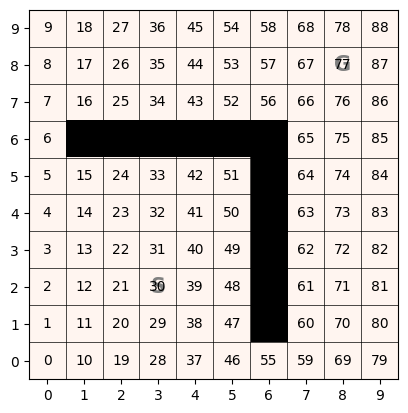

In [17]:
env.image()

Helper to plot a solution given the learned weight vector $\mathbf{w}$.

In [18]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0, state_features, q_hat
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function 
def plot_w(w, title=None):
    Q = np.array([[q_hat(s, a, w) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    
    return Q, V, pol

## Define a Fourier Basis Transformation

Fourier basis transformations are very useful and often work very well. The idea is to construct features as a weighted sum of cosine basis functions of different frequencies.
This is based on the idea that every signal can be decomposed into sin/cosine waves using the [Fourier transform](https://en.wikipedia.org/wiki/Fourier_transform). 

The method is described in the Sutton/Barto textbook and is based on:

> Konidaris, G., Osentoski, S., & Thomas, P. 2011. Value Function Approximation in Reinforcement Learning Using the Fourier Basis. Proceedings of the AAAI 
> Conference on Artificial Intelligence, 25(1), 380-385. http://doi.org/10.1609/aaai.v25i1.7903


The $i$-th feature in the order-$n$ Fourier cosine basis is defined as

$x_i(s) = cos(\pi \mathbf{s}^\top\mathbf{c}^i)$,

where $\mathbf{c}^i = (c^i_1,...,c^i_k)^\top$ is a coefficient vector defining the frequency, where $c^i_j \in {0,...,n}$ for $j=1,...,k$ and $i= 1, ..,(n+1)^k$.

We can create the coefficients $\mathbf{c}$ given the dimensionality of the state feature vector and the order of the Fourier features. The order roughly means how many different frequency we use. Using higher order means that a more complicated problem structure can be learned. 

In [19]:
from itertools import product
# this is the cartesian product

def create_fourier_basis_coefs(dim, order): 
    """ Create Fourier basis coefficients for given dimension and order. 
        param dim: dimension of the state features
        param order: order of the Fourier basis
    """  
    return np.array(list(product(range(order+1), repeat=dim)))

Here I create coefficients for order-2 Fourier features.

In [20]:
create_fourier_basis_coefs(2, 2)

array([[0, 0],
       [0, 1],
       [0, 2],
       [1, 0],
       [1, 1],
       [1, 2],
       [2, 0],
       [2, 1],
       [2, 2]])

0 means that the feature is constant and 1 is the frequency (one half-wave). Next, I define a transformation function that takes in a states x and y coordinate and calculates the Fourier features. We need to scale the state features to the interval $[0,1]$. I do this by manually specifying the min and max for 
x and y.

In [21]:
def transformation_fourier_basis(min, max, order):
    """ Create a Fourier basis transformation function for given min/max ranges and order.
        param min: minimum values for each dimension
        param max: maximum values for each dimension
        param order: order of the Fourier basis
    """  
    coefs = create_fourier_basis_coefs(len(min), order)
    
    def fourier_basis(s):
        # normalize state to [0,1]
        norm_s = (s - min) / (max - min)
        return np.cos(np.pi * np.dot(coefs, norm_s))
    
    return fourier_basis

In [22]:
trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

In [23]:
trans_fb((1,1))

array([1.  , 0.95, 0.81, 0.95, 0.81, 0.59, 0.81, 0.59, 0.31])

We get for coordinate $(1,1)$ four feature values, one for each of the basis coefficients which represents the weight (amplitude) of that component.

### Visualizing the Basis Functions

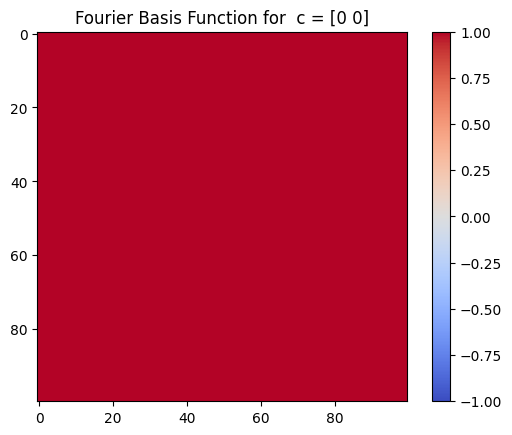

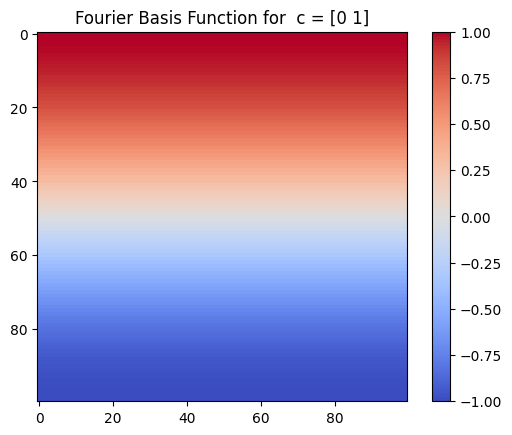

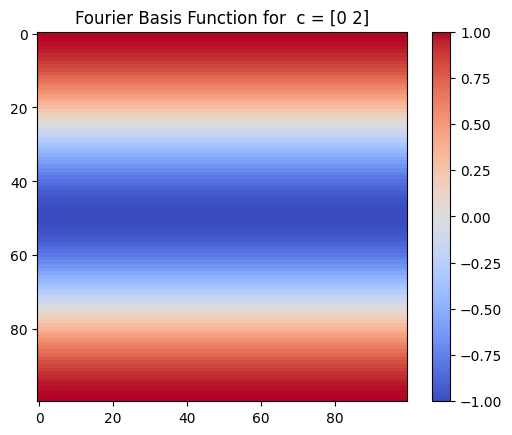

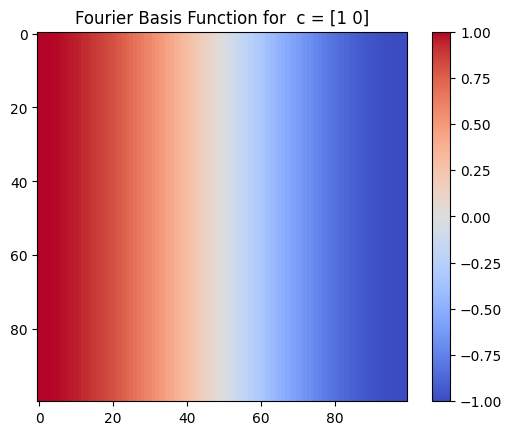

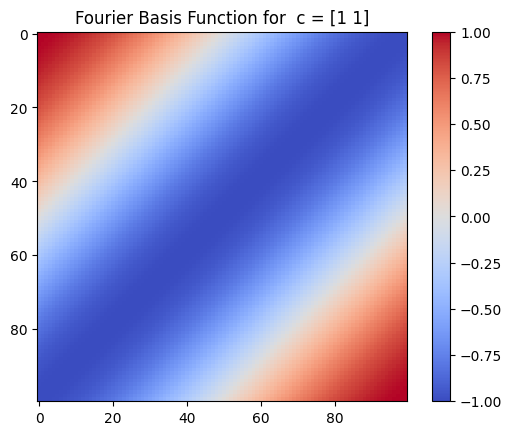

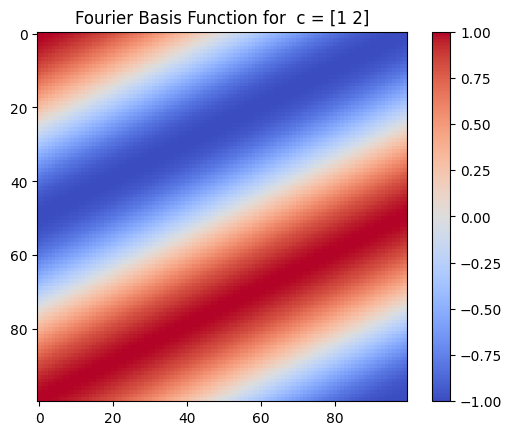

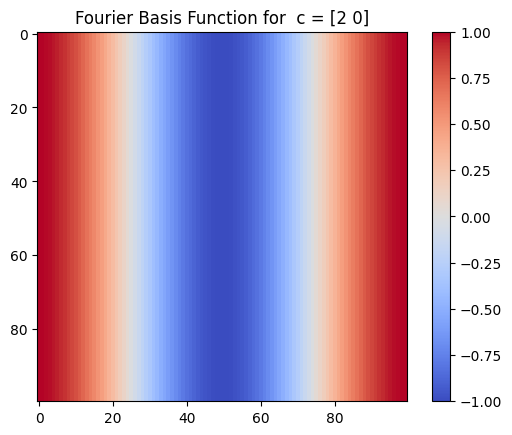

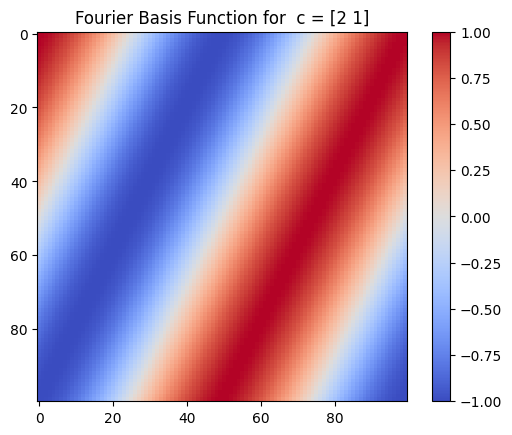

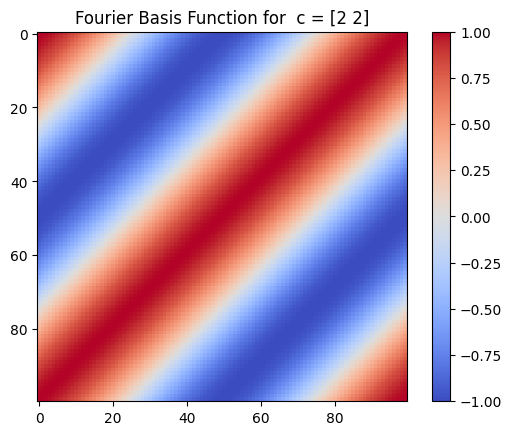

In [24]:
from matplotlib import pyplot as plt

dim = env.dims

x = np.linspace(0, dim[0], 100)
y = np.linspace(0, dim[1], 100)
X, Y = np.meshgrid(x, y)

c = create_fourier_basis_coefs(2, 2)

# plot the Q-function for each action
for i in range(len(c)):
    Z = np.array([trans_fb((x, y))[i] for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

    plt.imshow(Z, cmap='coolwarm', clim=(-1,1))
    plt.title(f'Fourier Basis Function for  c = {c[i]}')
    plt.colorbar()
    plt.show()

### Learn With the Transformed Features

In [25]:
# overwrite state_features for the semi-gradient Sarsa implementation with Fourier basis features
def state_features(s):
    return trans_fb(env.decode(s))

gym_classics.algorithms.linear_approximation.state_features = state_features

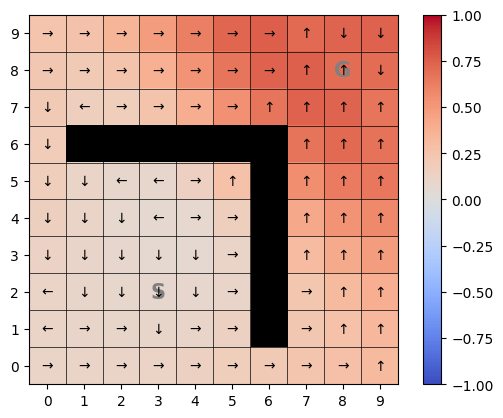

In [26]:
w = semi_gradient_Sarsa_0(env, n=5000, epsilon=0.3, alpha=0.001, gamma=.9, max_episode_length = 1000, verbose=False)
Q, V, pol = plot_w(w)

An example episode for the learned policy.

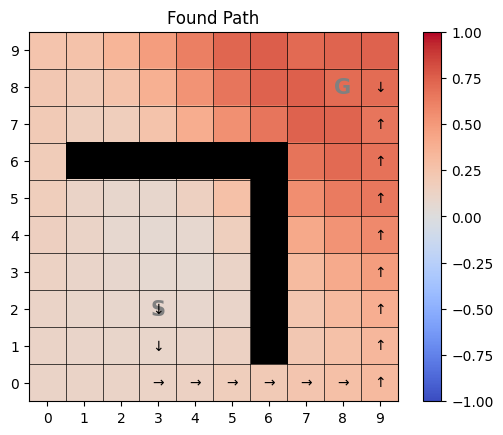

In [27]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))

### Inspect the Learned Weights

In [28]:
w

array([ 0.32, -0.17,  0.  , -0.18, -0.01,  0.05, -0.01,  0.12, -0.06,
       -0.17,  0.04, -0.14, -0.02,  0.06, -0.02,  0.11, -0.06, -0.19,
        0.04, -0.17,  0.09, -0.01,  0.01,  0.04, -0.04, -0.17,  0.01,
       -0.18,  0.09,  0.02,  0.02,  0.03, -0.02,  0.  ,  0.  ,  0.  ,
        0.  ])

We can look at the learned Q values and the final value function.

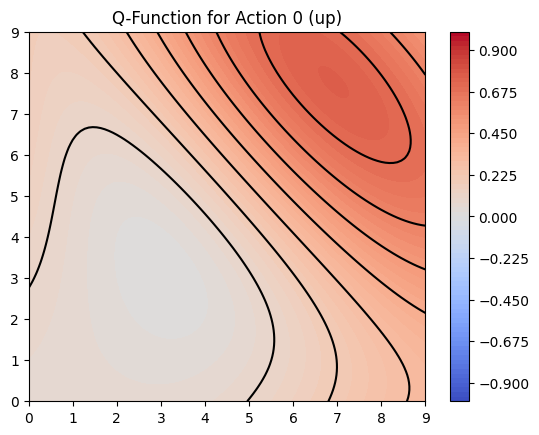

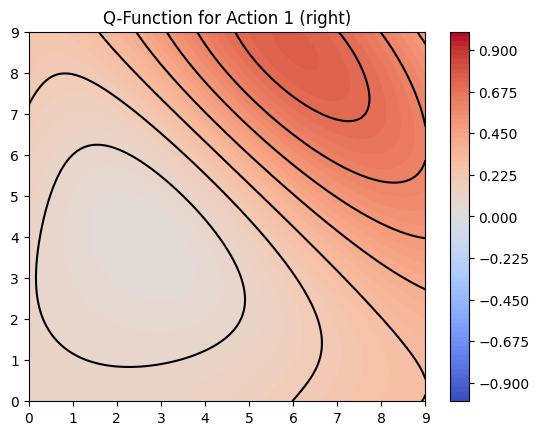

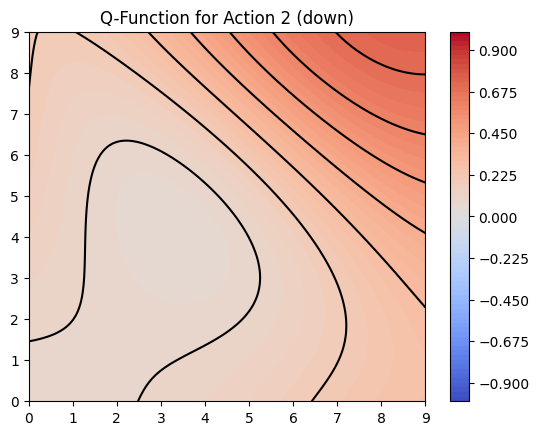

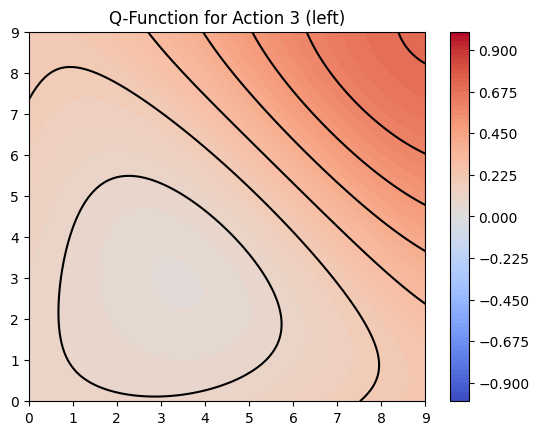

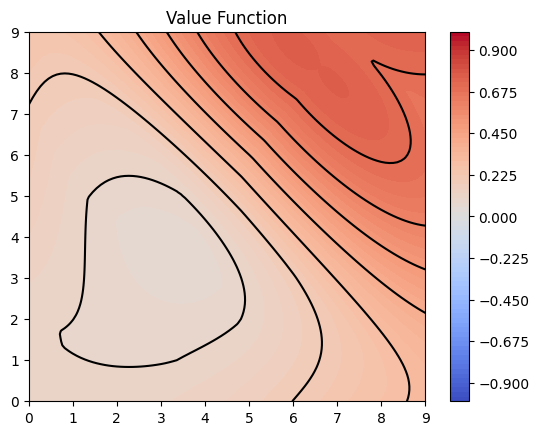

In [29]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    x_s = trans_fb(np.array([x, y]))
    sf_len = len(x_s) -1
    active_weights = [0] + list(range(a*sf_len+1, a*sf_len+sf_len+1))
    return np.dot(w[active_weights], x_s)

x = np.linspace(0, env.dims[0]-1, 100)
y = np.linspace(0, env.dims[1]-1, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=list(np.linspace(-1, 1, 81)))
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.decode_action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm',levels=np.linspace(-1, 1, 81))
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()

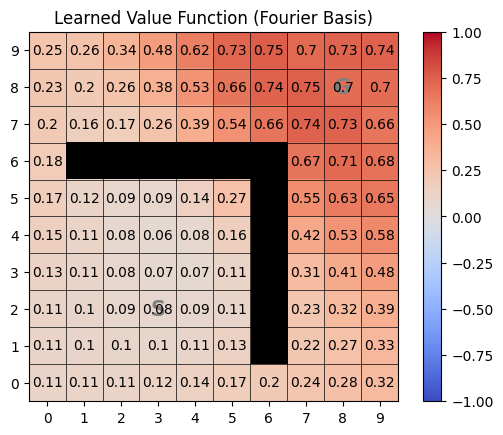

In [30]:
env.image(V, labels = True, clim=(-1,1), title= 'Learned Value Function (Fourier Basis)')

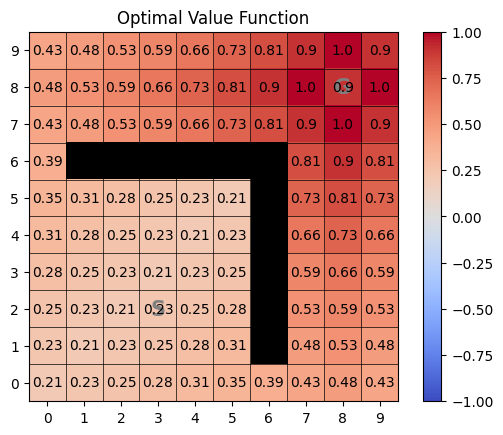

MSVE: 0.191769271618313, sqrt(MSVE): 0.4379146853193131


In [31]:
from gym_classics.algorithms.dynamic_programming import value_iteration
V_true = value_iteration(env, discount = .9)
env.image(V_true, labels=True, clim=(-1,1), title= 'Optimal Value Function') 

# unweighted mean squared value error
def MSVE(V, V_true):
    return np.sqrt(np.mean((V - V_true)**2))

# compute MSVE excluding terminal states
msve = MSVE(V[:-2], V_true[:-2])
msve_sqrt = np.sqrt(msve)

print(f"MSVE: {msve}, sqrt(MSVE): {msve_sqrt}")

The value function approximation can be improved using higher order features.

# Final Thoughts

There are many advantages of using linear approximation with Fourier features!

* The method is a linear approximation which means that if $\alpha$ is small enough and reduced over time, then convergence is guaranteed!
* Fourier features are very powerful and easy to use.
* Learning is typically relatively fast.
* Changing the order can help learn more complicated problems.
* Fourier basis features and tile coding are probably the most popular transformations used for linear approximation.



&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)